In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid")

BASE_DIR = Path.cwd()
DERIVED_DIR = BASE_DIR / "derived"

PLOTS_DIR = DERIVED_DIR / "plots" / "lebarde_vs_zugdidi"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str, dpi: int = 200):
    out = PLOTS_DIR / f"{name}.png"
    plt.savefig(out, dpi=dpi, bbox_inches="tight")
    print("saved:", out)

LEBARDE_DAILY = DERIVED_DIR / "lebarde_daily_clean.csv"
LEBARDE_MONTHLY = DERIVED_DIR / "lebarde_monthly_clean.csv"
ZUGDIDI_DAILY = DERIVED_DIR / "zugdidi_daily_clean.csv"
ZUGDIDI_MONTHLY = DERIVED_DIR / "zugdidi_monthly_clean.csv"

OUT_HYDRO = DERIVED_DIR / "lebarde_hydro_indices.csv"
OUT_EDW_DAILY = DERIVED_DIR / "edw_daily_lebarde_vs_zugdidi.csv"

LEBARDE_DAILY, ZUGDIDI_DAILY

(WindowsPath('c:/Users/Lenovo/OneDrive/문서/Sustainability Project/Peru_Weather_Stations-20260224T230622Z-3-001/Peru_Weather_Stations/Caucasus_Weather_Stations/derived/lebarde_daily_clean.csv'),
 WindowsPath('c:/Users/Lenovo/OneDrive/문서/Sustainability Project/Peru_Weather_Stations-20260224T230622Z-3-001/Peru_Weather_Stations/Caucasus_Weather_Stations/derived/zugdidi_daily_clean.csv'))

In [2]:
def read_daily(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date"]).sort_values("date")
    return df


def read_monthly(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["year"] = pd.to_numeric(df["year"], errors="coerce")
    df["month"] = pd.to_numeric(df["month"], errors="coerce")
    df = df.dropna(subset=["year", "month"])
    df["year"] = df["year"].astype(int)
    df["month"] = df["month"].astype(int)
    df["date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))
    return df.sort_values("date")


lebarde_daily = read_daily(LEBARDE_DAILY)
lebarde_monthly = read_monthly(LEBARDE_MONTHLY)
zugdidi_daily = read_daily(ZUGDIDI_DAILY)
zugdidi_monthly = read_monthly(ZUGDIDI_MONTHLY)

lebarde_daily.head()

,station_id,station_name,elevation_m,latitude,longitude,date,tmean_c,tmax_c,tmin_c,dtr_c,n_obs_day,precip_mm
0,lebarde,Lebarde,1491.0,42.44,42.49,1936-06-01,8.5,16.5,4.1,12.4,1,0.3
1,lebarde,Lebarde,1491.0,42.44,42.49,1936-06-02,10.5,17.5,4.0,13.5,1,1.0
2,lebarde,Lebarde,1491.0,42.44,42.49,1936-06-03,12.8,20.0,6.3,13.7,1,0.0
3,lebarde,Lebarde,1491.0,42.44,42.49,1936-06-04,11.1,14.5,7.6,6.9,1,15.5
4,lebarde,Lebarde,1491.0,42.44,42.49,1936-06-05,8.3,10.5,7.4,3.1,1,12.3


Lebarde warming rate (tmean_c_month): -0.079 °C/decade


saved: c:\Users\Lenovo\OneDrive\문서\Sustainability Project\Peru_Weather_Stations-20260224T230622Z-3-001\Peru_Weather_Stations\Caucasus_Weather_Stations\derived\plots\lebarde_vs_zugdidi\lebarde_monthly_tmean_trend.png


saved: c:\Users\Lenovo\OneDrive\문서\Sustainability Project\Peru_Weather_Stations-20260224T230622Z-3-001\Peru_Weather_Stations\Caucasus_Weather_Stations\derived\plots\lebarde_vs_zugdidi\lebarde_seasonal_cycle.png


saved: c:\Users\Lenovo\OneDrive\문서\Sustainability Project\Peru_Weather_Stations-20260224T230622Z-3-001\Peru_Weather_Stations\Caucasus_Weather_Stations\derived\plots\lebarde_vs_zugdidi\lebarde_monthly_heatmap.png


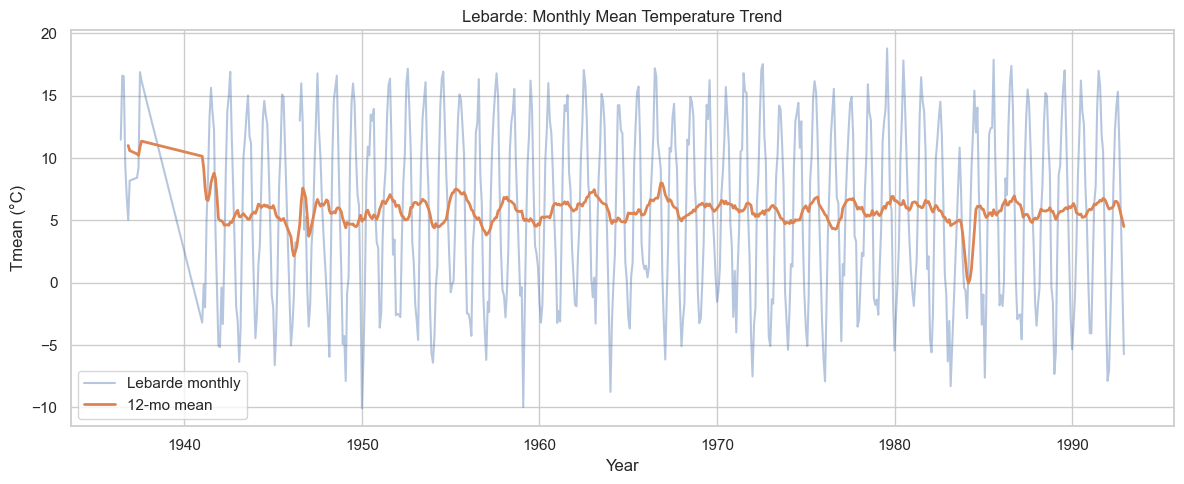

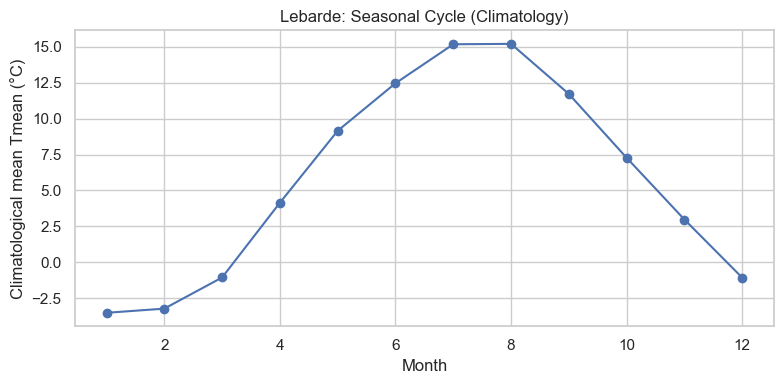

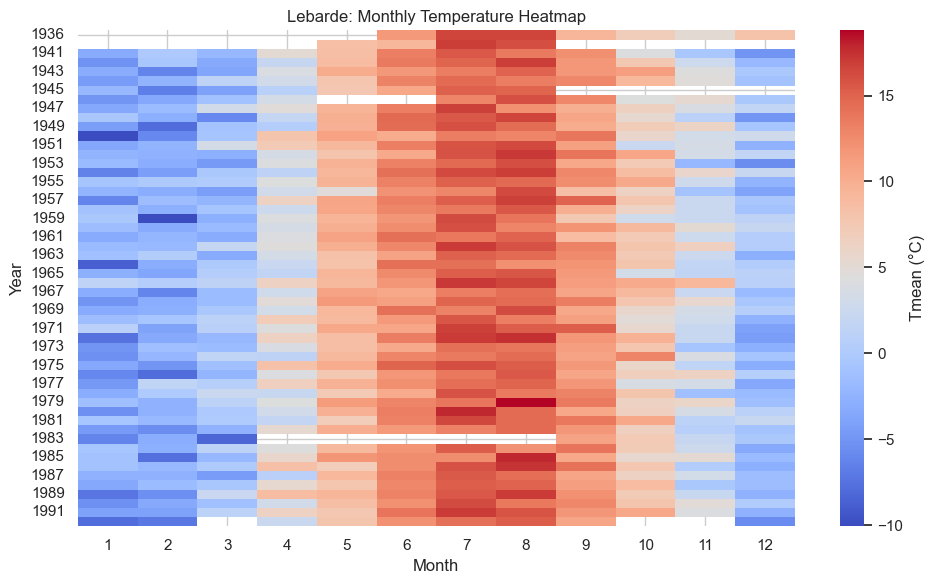

In [3]:
def fit_linear_trend_monthly(df: pd.DataFrame, value_col: str) -> float:
    series = df.dropna(subset=[value_col]).copy()
    if series.empty:
        return np.nan
    years = series["year"].to_numpy() + (series["month"].to_numpy() - 0.5) / 12.0
    y = series[value_col].to_numpy()
    slope_year, _ = np.polyfit(years, y, 1)
    return slope_year * 10.0


slope_decade = fit_linear_trend_monthly(lebarde_monthly, "tmean_c_month")
print(f"Lebarde warming rate (tmean_c_month): {slope_decade:.3f} °C/decade" if not np.isnan(slope_decade) else "Trend unavailable")

plt.figure(figsize=(12, 5))
plt.plot(lebarde_monthly["date"], lebarde_monthly["tmean_c_month"], alpha=0.4, label="Lebarde monthly")
plt.plot(
    lebarde_monthly["date"],
    lebarde_monthly["tmean_c_month"].rolling(12, min_periods=6).mean(),
    linewidth=2,
    label="12-mo mean",
)
plt.title("Lebarde: Monthly Mean Temperature Trend")
plt.xlabel("Year")
plt.ylabel("Tmean (°C)")
plt.legend()
plt.tight_layout()
savefig("lebarde_monthly_tmean_trend")

plt.figure(figsize=(8, 4))
seasonal = lebarde_monthly.groupby("month")["tmean_c_month"].mean()
plt.plot(seasonal.index, seasonal.values, marker="o")
plt.title("Lebarde: Seasonal Cycle (Climatology)")
plt.xlabel("Month")
plt.ylabel("Climatological mean Tmean (°C)")
plt.tight_layout()
savefig("lebarde_seasonal_cycle")

pivot = lebarde_monthly.pivot(index="year", columns="month", values="tmean_c_month")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap="coolwarm", cbar_kws={"label": "Tmean (°C)"})
plt.title("Lebarde: Monthly Temperature Heatmap")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
savefig("lebarde_monthly_heatmap")

Freezing days per year (last 5):
date
1988     98
1989     93
1990     91
1991     87
1992    100
Name: tmean_c, dtype: int64

Heatwave days per year (Tmean > 90th pct) (last 5):
date
1988    37
1989    45
1990    31
1991    45
1992    31
Name: tmean_c, dtype: int64


saved: c:\Users\Lenovo\OneDrive\문서\Sustainability Project\Peru_Weather_Stations-20260224T230622Z-3-001\Peru_Weather_Stations\Caucasus_Weather_Stations\derived\plots\lebarde_vs_zugdidi\lebarde_freezing_days_per_year.png


saved: c:\Users\Lenovo\OneDrive\문서\Sustainability Project\Peru_Weather_Stations-20260224T230622Z-3-001\Peru_Weather_Stations\Caucasus_Weather_Stations\derived\plots\lebarde_vs_zugdidi\lebarde_heatwave_days_per_year.png


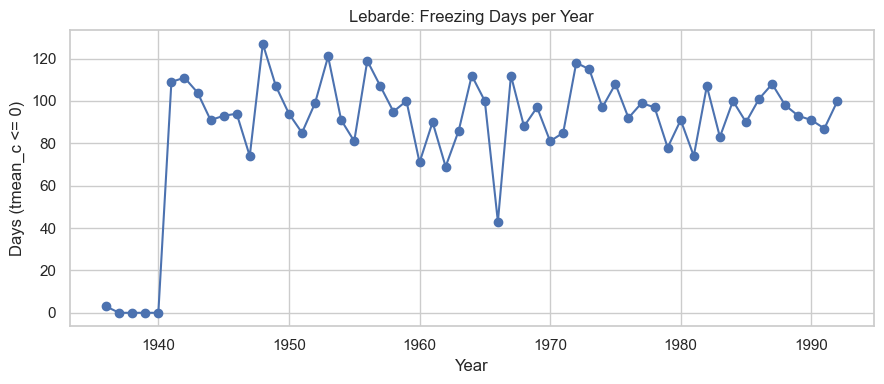

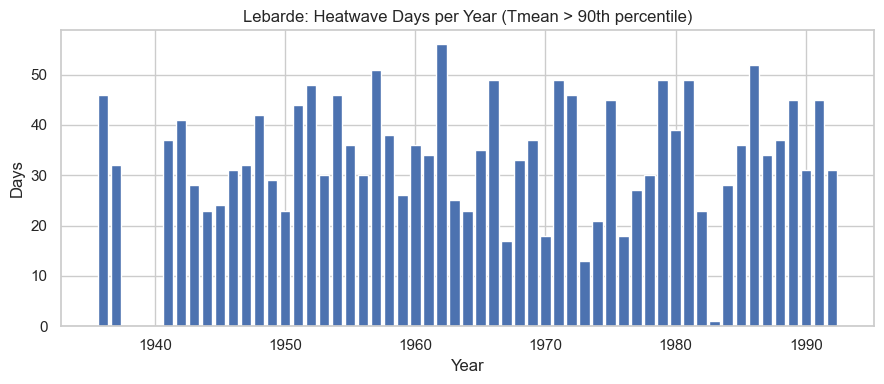

In [4]:
# Daily extremes and variability (Lebarde)
df = lebarde_daily.copy().set_index("date").sort_index()

freezing_per_year = (df["tmean_c"] <= 0).resample("YE").sum()
freezing_per_year.index = freezing_per_year.index.year

thresh90 = df["tmean_c"].quantile(0.9)
hot_days_per_year = (df["tmean_c"] > thresh90).resample("YE").sum()
hot_days_per_year.index = hot_days_per_year.index.year

print("Freezing days per year (last 5):")
print(freezing_per_year.tail())
print("\nHeatwave days per year (Tmean > 90th pct) (last 5):")
print(hot_days_per_year.tail())

plt.figure(figsize=(9, 4))
plt.plot(freezing_per_year.index, freezing_per_year.values, marker="o")
plt.title("Lebarde: Freezing Days per Year")
plt.xlabel("Year")
plt.ylabel("Days (tmean_c <= 0)")
plt.tight_layout()
savefig("lebarde_freezing_days_per_year")

plt.figure(figsize=(9, 4))
plt.bar(hot_days_per_year.index, hot_days_per_year.values)
plt.title("Lebarde: Heatwave Days per Year (Tmean > 90th percentile)")
plt.xlabel("Year")
plt.ylabel("Days")
plt.tight_layout()
savefig("lebarde_heatwave_days_per_year")

In [5]:
# Hydro-climate indices (Lebarde)
hydro = lebarde_daily.copy()
hydro["date"] = pd.to_datetime(hydro["date"], errors="coerce")
hydro = hydro.dropna(subset=["date"])

hydro["hydro_year"] = np.where(hydro["date"].dt.month >= 10, hydro["date"].dt.year + 1, hydro["date"].dt.year)

hydro["pdd_degC"] = hydro["tmean_c"].clip(lower=0.0)
pdd = hydro.groupby("hydro_year")["pdd_degC"].sum().rename("pdd_degC_sum").reset_index()

freeze = (hydro["tmean_c"] <= 0.0).groupby(hydro["hydro_year"]).sum().rename("n_freezing_days").reset_index()

heavy = (hydro["precip_mm"] >= 20.0).groupby(hydro["hydro_year"]).sum().rename("n_days_p>=20.0mm").reset_index()

lebarde_hydro = pdd.merge(freeze, on="hydro_year", how="outer").merge(heavy, on="hydro_year", how="outer").sort_values("hydro_year")
lebarde_hydro.to_csv(OUT_HYDRO, index=False)

lebarde_hydro.tail()

,hydro_year,pdd_degC_sum,n_freezing_days,n_days_p>=20.0mm
50,1989,2789.7,97,42
51,1990,2439.9,102,40
52,1991,2798.5,77,24
53,1992,2393.4,98,33
54,1993,0.0,31,2


saved: c:\Users\Lenovo\OneDrive\문서\Sustainability Project\Peru_Weather_Stations-20260224T230622Z-3-001\Peru_Weather_Stations\Caucasus_Weather_Stations\derived\plots\lebarde_vs_zugdidi\lebarde_pdd_by_hydro_year.png


saved: c:\Users\Lenovo\OneDrive\문서\Sustainability Project\Peru_Weather_Stations-20260224T230622Z-3-001\Peru_Weather_Stations\Caucasus_Weather_Stations\derived\plots\lebarde_vs_zugdidi\lebarde_freezing_and_heavy_precip_by_hydro_year.png


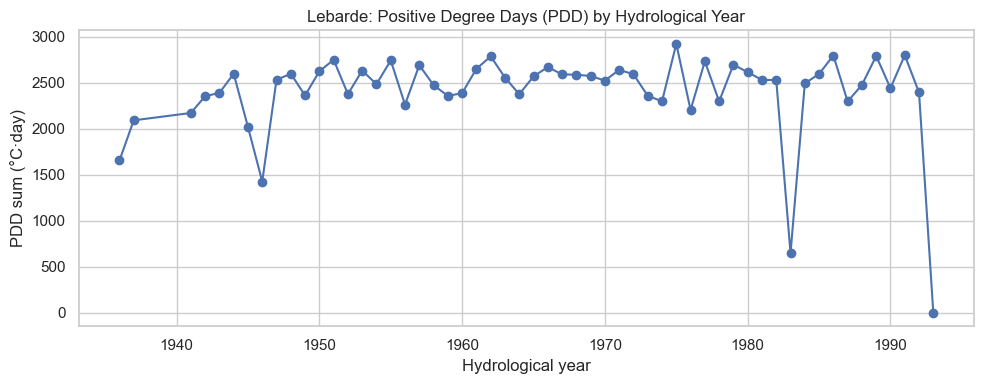

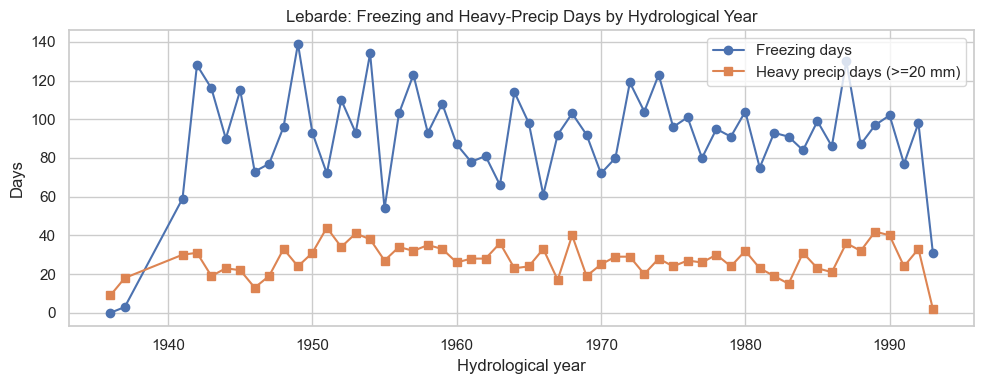

In [6]:
# Hydro indices plots
plt.figure(figsize=(10, 4))
plt.plot(lebarde_hydro["hydro_year"], lebarde_hydro["pdd_degC_sum"], marker="o")
plt.title("Lebarde: Positive Degree Days (PDD) by Hydrological Year")
plt.xlabel("Hydrological year")
plt.ylabel("PDD sum (°C·day)")
plt.tight_layout()
savefig("lebarde_pdd_by_hydro_year")

plt.figure(figsize=(10, 4))
plt.plot(lebarde_hydro["hydro_year"], lebarde_hydro["n_freezing_days"], marker="o", label="Freezing days")
plt.plot(lebarde_hydro["hydro_year"], lebarde_hydro["n_days_p>=20.0mm"], marker="s", label="Heavy precip days (>=20 mm)")
plt.title("Lebarde: Freezing and Heavy-Precip Days by Hydrological Year")
plt.xlabel("Hydrological year")
plt.ylabel("Days")
plt.legend()
plt.tight_layout()
savefig("lebarde_freezing_and_heavy_precip_by_hydro_year")

In [7]:
# EDW-style comparison: Lebarde (high) vs Zugdidi (low)
hi = lebarde_daily[["date", "tmean_c", "elevation_m"]].copy().rename(columns={"tmean_c": "tmean_hi", "elevation_m": "elev_hi_m"})
lo = zugdidi_daily[["date", "tmean_c", "elevation_m"]].copy().rename(columns={"tmean_c": "tmean_lo", "elevation_m": "elev_lo_m"})

hi["date"] = pd.to_datetime(hi["date"], errors="coerce")
lo["date"] = pd.to_datetime(lo["date"], errors="coerce")

edw = hi.merge(lo, on="date", how="inner")
edw = edw.dropna(subset=["tmean_hi", "tmean_lo", "elev_hi_m", "elev_lo_m"]).sort_values("date")

edw["delta_t_c"] = edw["tmean_hi"] - edw["tmean_lo"]
dz_100m = (edw["elev_hi_m"] - edw["elev_lo_m"]) / 100.0
edw["lapse_rate_c_per_100m"] = edw["delta_t_c"] / dz_100m

edw.to_csv(OUT_EDW_DAILY, index=False)

edw.head()

,date,tmean_hi,elev_hi_m,tmean_lo,elev_lo_m,delta_t_c,lapse_rate_c_per_100m
0,1936-06-01,8.5,1491.0,19.2,118.0,-10.7,-0.779315
1,1936-06-02,10.5,1491.0,23.4,118.0,-12.9,-0.939548
2,1936-06-03,12.8,1491.0,20.5,118.0,-7.7,-0.560816
3,1936-06-04,11.1,1491.0,17.4,118.0,-6.3,-0.458849
4,1936-06-05,8.3,1491.0,15.2,118.0,-6.9,-0.502549


EDW summary (Lebarde − Zugdidi):
  ΔT mean:   -7.994 °C
  Lapse mean:-0.582 °C/100m


saved: c:\Users\Lenovo\OneDrive\문서\Sustainability Project\Peru_Weather_Stations-20260224T230622Z-3-001\Peru_Weather_Stations\Caucasus_Weather_Stations\derived\plots\lebarde_vs_zugdidi\edw_deltaT_lebarde_minus_zugdidi.png


saved: c:\Users\Lenovo\OneDrive\문서\Sustainability Project\Peru_Weather_Stations-20260224T230622Z-3-001\Peru_Weather_Stations\Caucasus_Weather_Stations\derived\plots\lebarde_vs_zugdidi\edw_lapse_rate_lebarde_minus_zugdidi.png


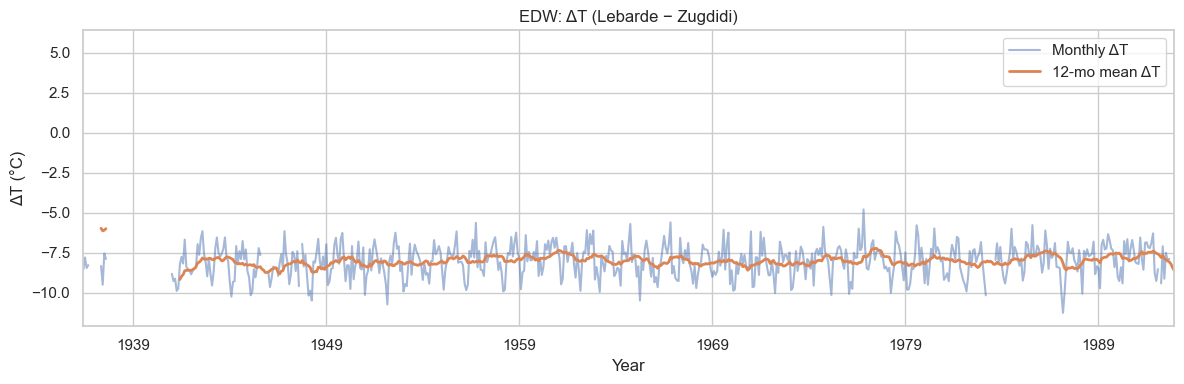

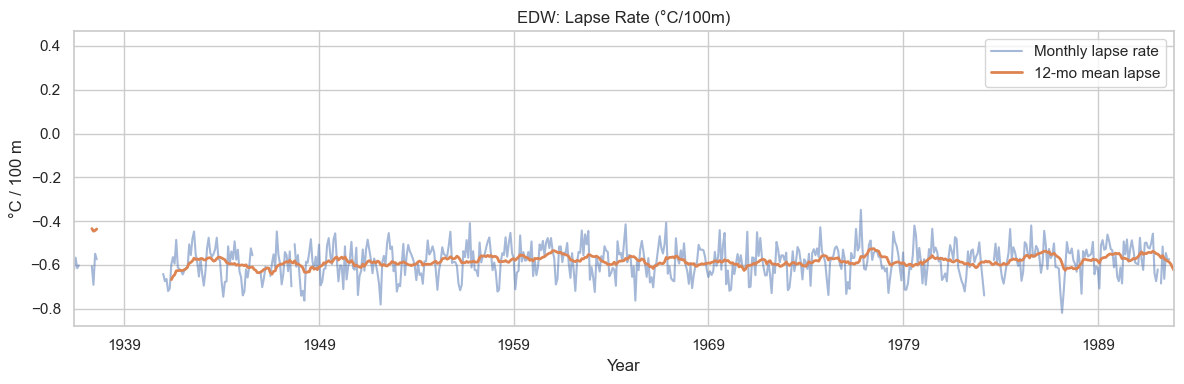

In [8]:
edw_ts = edw.copy().set_index("date").sort_index()
monthly_delta = edw_ts["delta_t_c"].resample("ME").mean()
monthly_lapse = edw_ts["lapse_rate_c_per_100m"].resample("ME").mean()

print("EDW summary (Lebarde − Zugdidi):")
print(f"  ΔT mean:   {monthly_delta.mean():.3f} °C")
print(f"  Lapse mean:{monthly_lapse.mean():.3f} °C/100m")

plt.figure(figsize=(12, 4))
monthly_delta.plot(alpha=0.5, label="Monthly ΔT")
monthly_delta.rolling(12, min_periods=6).mean().plot(linewidth=2, label="12-mo mean ΔT")
plt.title("EDW: ΔT (Lebarde − Zugdidi)")
plt.ylabel("ΔT (°C)")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
savefig("edw_deltaT_lebarde_minus_zugdidi")

plt.figure(figsize=(12, 4))
monthly_lapse.plot(alpha=0.5, label="Monthly lapse rate")
monthly_lapse.rolling(12, min_periods=6).mean().plot(linewidth=2, label="12-mo mean lapse")
plt.title("EDW: Lapse Rate (°C/100m)")
plt.ylabel("°C / 100 m")
plt.xlabel("Year")
plt.legend()
plt.tight_layout()
savefig("edw_lapse_rate_lebarde_minus_zugdidi")